In [1]:
import os
from shutil import move

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from kagglehub import kagglehub
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import random_split
from torchvision import datasets, transforms
from tqdm import tqdm



In [2]:
# Generalized permanent dataset path
home_dir = os.path.expanduser("~")  # Gets the user's home directory
permanent_path = os.path.join(home_dir, "datasets")

# Download dataset if it doesn't exist
if not os.path.exists(permanent_path):
    print("Downloading dataset...")
    temp_path = kagglehub.dataset_download("subhaditya/fer2013plus")  # Temporary download path
    print("Moving dataset to permanent location...")
    move(temp_path, permanent_path)
    print("Dataset moved to:", permanent_path)
else:
    print("Dataset already exists at:", permanent_path)

# Identify train and test directories dynamically
train_dir = os.path.join(permanent_path, "fer2013plus", "fer2013", "train")
test_dir = os.path.join(permanent_path, "fer2013plus", "fer2013", "test")

Dataset already exists at: /home/omarhammad/datasets


In [3]:
# Paths for augmented datasets
augmented_train_dir = os.path.join(permanent_path, "fer2013plus/fer2013/train_augmented")
augmented_test_dir = os.path.join(permanent_path, "fer2013plus/fer2013/test_augmented")

# Define augmentations for train and processing for test
train_augment_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure image is grayscale (1 channel)
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
    transforms.ToTensor(),  # Convert to tensor at the end
    transforms.Normalize((0.5,), (0.5,))  # Normalize after tensor conversion
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure image is grayscale (1 channel)
    transforms.ToTensor(),  # Convert to tensor at the beginning
    transforms.Normalize((0.5,), (0.5,))  # Normalize during loading
])

# Check if the augmented datasets exist
if not os.path.exists(augmented_train_dir) or not os.path.exists(augmented_test_dir):
    print("Augmented datasets not found. Creating augmented datasets...")

    # Use GPU for processing if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Create and save the augmented train dataset
    print("Processing train dataset...")
    for label in os.listdir(train_dir):
        label_dir = os.path.join(train_dir, label)
        save_dir = os.path.join(augmented_train_dir, label)
        os.makedirs(save_dir, exist_ok=True)
        for img_name in tqdm(os.listdir(label_dir), desc=f"Processing {label}"):
            img_path = os.path.join(label_dir, img_name)
            img = Image.open(img_path).convert("L")  # Convert to grayscale (1 channel)

            # Apply augmentations to the PIL Image
            for i in range(5):  # Generate 5 augmented images per original
                augmented_img = train_augment_transform(img)  # Apply transforms directly to the PIL Image
                augmented_img_pil = transforms.ToPILImage()(augmented_img)  # Convert tensor back to PIL Image for saving
                augmented_img_pil.save(os.path.join(save_dir, f"{os.path.splitext(img_name)[0]}_aug_{i}.png"))

    # Process and save the test dataset
    print("Processing test dataset...")
    for label in os.listdir(test_dir):
        label_dir = os.path.join(test_dir, label)
        save_dir = os.path.join(augmented_test_dir, label)
        os.makedirs(save_dir, exist_ok=True)
        for img_name in tqdm(os.listdir(label_dir), desc=f"Processing {label}"):
            img_path = os.path.join(label_dir, img_name)
            img = Image.open(img_path).convert("L")  # Convert to grayscale (1 channel)

            # Apply test transforms directly
            processed_img = test_transform(img)
            processed_img_pil = transforms.ToPILImage()(processed_img)  # Convert tensor back to PIL Image for saving
            processed_img_pil.save(os.path.join(save_dir, img_name))
else:
    print("Augmented datasets already exist. Skipping processing.")

# Reload processed datasets with normalization applied during loading
train_dataset = datasets.ImageFolder(augmented_train_dir, transform=train_augment_transform)
test_dataset = datasets.ImageFolder(augmented_test_dir, transform=test_transform)


Augmented datasets already exist. Skipping processing.


In [4]:
# Dataset sizes
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 141930
Test dataset size: 7099


In [5]:
def create_dataloaders(train_dataset, test_dataset, batch_size, val_split=0.2):
    # Split train_dataset into training and validation datasets
    train_size = int((1 - val_split) * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    # Extract labels for the training subset
    train_labels = [train_dataset.targets[i] for i in train_subset.indices]

    # Calculate class counts and weights
    class_counts = np.bincount(train_labels)  # Assumes labels are sequential integers starting from 0
    class_weights = 1. / np.sqrt(class_counts + 1e-6)  # Avoid division by zero
    class_weights = torch.tensor(class_weights, dtype=torch.float32)

    # Log class weights for debugging
    print(f"Class counts: {class_counts}")
    print(f"Class weights: {class_weights}")

    # Create sample weights for WeightedRandomSampler
    sample_weights = [class_weights[label] for label in train_labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    # Create DataLoaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, sampler=sampler)  # Stratified sampling for training
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)  # No sampling for validation
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)  # Random shuffle for test

    # Log dataset sizes for verification
    print(f"Train size: {len(train_subset)}, Validation size: {len(val_subset)}, Test size: {len(test_dataset)}")

    return train_loader, val_loader, test_loader


In [6]:
def evaluate_model(model, data_loader):
    """
    Evaluates the model's performance on a given dataset.

    Args:
        model: The trained model to evaluate.
        data_loader: DataLoader for the dataset to evaluate.

    Returns:
        float: Accuracy of the model on the dataset.
    """
    # Set the device (CUDA if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move model to the device
    model = model.to(device)

    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            # Move data to the same device as model
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy


In [7]:
def visualize_predictions(model, data_loader, classes, num_images=8, device='cpu'):
    # Set model to evaluation mode
    model.eval()
    model.to(device)

    # Get a random batch of data
    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    # Get predictions from the model
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    # Limit the number of images to visualize
    num_images = min(num_images, len(images))

    # Create a grid of images
    rows = (num_images + 1) // 2  # Number of rows for layout
    cols = 2  # Fixed number of columns

    plt.figure(figsize=(15, rows * 5))  # Adjust figure size
    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)

        # Convert tensor to numpy array for display
        img = images[i].cpu().permute(1, 2, 0).numpy()  # Rearrange dimensions for matplotlib

        plt.imshow(img)  # Display the original image

        # Add ground truth and predicted labels
        true_label = classes[labels[i].item()]
        pred_label = classes[predicted[i].item()]
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=12)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


In [8]:
class CNN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, 8)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [9]:
train_loader,_, test_loader = create_dataloaders(train_dataset, test_dataset, 38)


Class counts: [ 9849   664   755  2572 30096 41282 14059 14267]
Class weights: tensor([0.0101, 0.0388, 0.0364, 0.0197, 0.0058, 0.0049, 0.0084, 0.0084])
Train size: 113544, Validation size: 28386, Test size: 7099


In [10]:
# Initialize the model with the same architecture
cnn_model = CNN()

# Map to the correct device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the state_dict with map_location
# initial_cnn_model and best_cnn_model
state_dict = torch.load("best_cnn_model.pth", map_location=device, weights_only=True)
cnn_model.load_state_dict(state_dict)

# Move the model to the correct device and set to eval mode
cnn_model.to(device)
cnn_model.eval()


CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=8, bias=True)
)

In [11]:
train_accuracy = evaluate_model(cnn_model, train_loader)
print(f"Train Accuracy: {train_accuracy:.4f}")

Train Accuracy: 0.8130


In [12]:
test_accuracy = evaluate_model(cnn_model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7291


In [13]:
# Prepare to count predictions for each class
classes = train_dataset.classes  # Get class names from the dataset
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# Set the device (CUDA if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move the model to the selected device
cnn_model = cnn_model.to(device)

# Disable gradients for evaluation
with torch.no_grad():
    for data in test_loader:
        images, labels = data

        # Move data to the same device as the model
        images, labels = images.to(device), labels.to(device)

        # Get predictions from the model
        outputs = cnn_model(images)
        _, predictions = torch.max(outputs, 1)  # Get predicted class indices

        # Collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            label_name = classes[label.item()]  # Convert label index to class name
            if label == prediction:
                correct_pred[label_name] += 1
            total_pred[label_name] += 1

# Print accuracy for each class
for classname, correct_count in correct_pred.items():
    if total_pred[classname] > 0:  # Avoid division by zero
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:10s} is {accuracy:.1f} %')
    else:
        print(f'No predictions for class: {classname}')


Accuracy for class: anger      is 61.3 %
Accuracy for class: contempt   is 21.6 %
Accuracy for class: disgust    is 38.6 %
Accuracy for class: fear       is 40.7 %
Accuracy for class: happiness  is 84.2 %
Accuracy for class: neutral    is 74.4 %
Accuracy for class: sadness    is 58.2 %
Accuracy for class: surprise   is 79.0 %


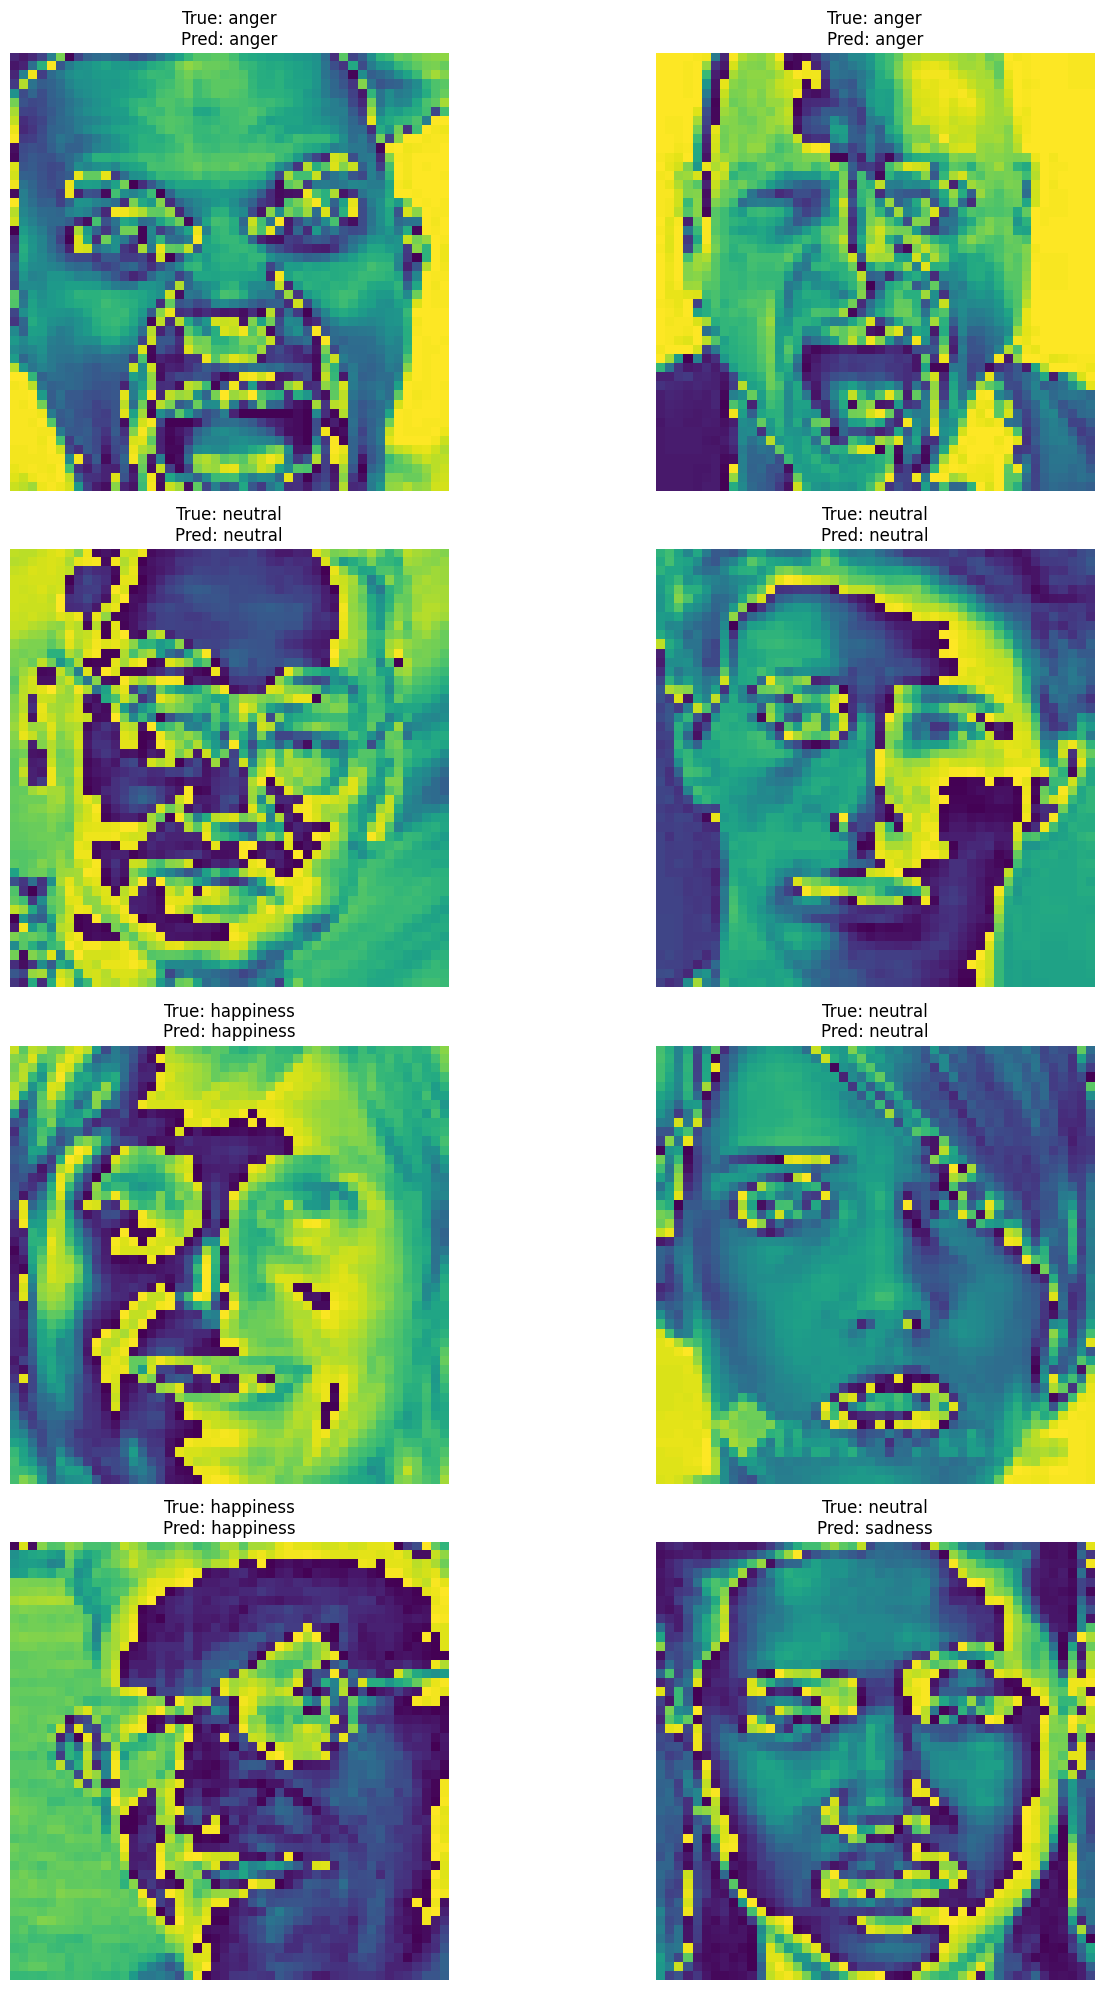

In [14]:
# Define class names
classes = train_dataset.classes  # Assuming you use ImageFolder or a similar dataset

# Visualize predictions
visualize_predictions(
    model=cnn_model,  # Your trained model
    data_loader=test_loader,  # DataLoader for the test dataset
    classes=classes,  # Class names
    num_images=8,  # Number of images to visualize
    device='cpu'  # Use 'cuda' if running on GPU
)
